In [7]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

$$
f(x)=x^2+x-10
$$

2.7015621187164727 3.090860900556436e-13


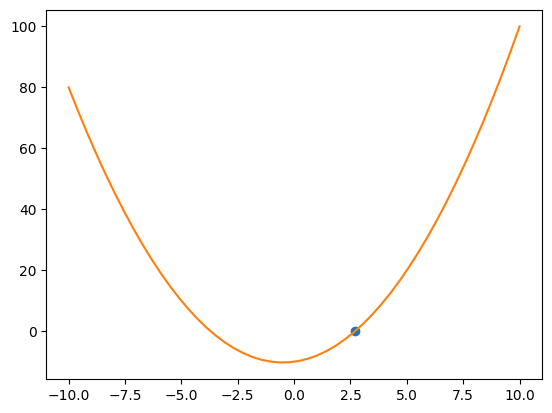

In [9]:
def func(x):
    return x**2+x-10
def fprime(x):
    return 2*x+1

x=1 # initial guess
tol=1e-10
err=abs(func(x))
while err>tol:
    x=x-func(x)/fprime(x)
    err=abs(func(x))
print(x,err)


import numpy as np
import matplotlib.pyplot as plt
plt.plot(x,func(x),'o')
xs=np.linspace(-10,10)
ys=func(xs)
plt.plot(xs,ys)

$$
f(x)=x^2+x-10
\newline
f^\prime(x)=2x+1
\newline
f^{\prime\prime}(x)=2
\newline
h=\frac{-f^\prime(x_n)\pm\sqrt{[f^\prime(x_n)]^2-2f(x_n)f^{\prime\prime}(x_n)}}{f^{\prime\prime}(x_n)}
$$

2.701562118716442 1.1368683772161603e-13


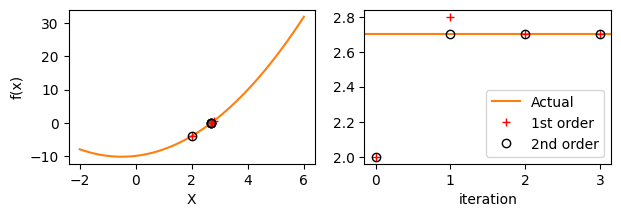

In [49]:
import numpy as np
import matplotlib.pyplot as plt
fig=plt.figure(figsize=(7,2))
ax1=fig.add_subplot(121)
ax2=fig.add_subplot(122)
ax1.plot(x,func(x),'o')
xs=np.linspace(-2,6)
ys=func(xs)
l,=ax1.plot(xs,ys,label='Actual')


def func(x):
    return x**2+x-10
def fprime(x):
    return 2*x+1
def fpp():
    return 2

def get_h(f,fp,fpp):
    det=fp**2-2*f*fpp
    h1=(-fp+np.sqrt(det))/fpp
    h2=(-fp-np.sqrt(det))/fpp
    if h1>h2: return h1
    return h2

x=2 # initial guess
x2nd=x ## initial guess for 2nd order
tol=1e-10
err=abs(func(x))
k=0
while err>tol:
    ax1.plot(x,func(x),'r+')
    ax1.plot(x2nd,func(x2nd),'ko',mfc='None')
    ax2.plot(k,x,'r+')
    ax2.plot(k,x2nd,'ko',mfc='None')
    x=x-func(x)/fprime(x)
    h=get_h(func(x2nd),fprime(x2nd),fpp())
    x2nd=x2nd+h
    #x2nd=x2nd+get_h(func(x),fp,fpp)
    err=abs(func(x))
    k+=1
print(x,err)
ax2.axhline(x,c=l.get_color(),label='Actual',zorder=-1)
ax2.plot(np.nan,np.nan,'r+',label='1st order')
ax2.plot(np.nan,np.nan,'ko',label='2nd order',mfc='None')
ax2.set_xlabel('iteration')
ax1.set_xlabel('X')
ax1.set_ylabel('f(x)')
ax2.legend()


0 -0.1
1 0.29842051270785386
2 0.38898636259884795
3 0.39257309442820076
4 0.39257867111285927


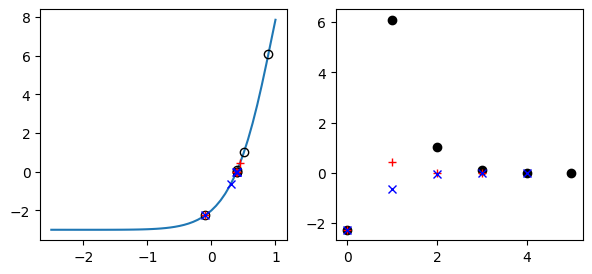

In [110]:
import matplotlib.pyplot as plt
import numpy as np

def f(x):
    return np.cos(x)*np.exp(3*x)-3
def fp(x):
    return np.cos(x)*np.exp(3*x)*3-np.sin(x)*np.exp(3*x)
def fpp(x):
    return -np.sin(x)*np.exp(3*x)*3+np.cos(x)*np.exp(3*x)*9
def h(x): # 2nd order NR
    F=f(x)
    p=fp(x)
    pp=fpp(x)

    det=p**2-2*F*pp
    det=np.sqrt(det)
    h1=-p+det
    h1=h1/pp

    h2=-p-det
    h2=h2/pp
    if abs(h1)<abs(h2): return h1
    else: return h2

def Halley(x): ## Halley's term
    F=f(x)
    p=fp(x)
    pp=fpp(x)
    return 2*F*p/(2*p**2-F*pp)

xs=np.linspace(-2.5,1)
ys=func(xs)

fig=plt.figure(figsize=(7,3))
ax1=fig.add_subplot(121)
ax2=fig.add_subplot(122)
ax1.plot(xs,ys)

xinit=-0.1
tol=1e-10
## Newton Raphson
x=xinit
err=tol*2
i=0
while err>tol:
    ax1.plot(x,f(x),'ko',mfc='None')
    ax2.plot(i,f(x),'ko')
    x+=-f(x)/fp(x)
    err=abs(f(x))
    i+=1

## 2nd order
x=xinit
err=tol*2
i=0
while err>tol:
    ax1.plot(x,f(x),'r+')
    ax2.plot(i,f(x),'r+')
    x+=+h(x) # here it is + sign.
    err=abs(f(x))
    i+=1

## Halley's method
## 2nd order
x=xinit
err=tol*2
i=0
while err>tol:
    print(i,x)
    ax1.plot(x,f(x),'bx')
    ax2.plot(i,f(x),'bx')
    x-=Halley(x) # note the minus sign here!
    err=abs(f(x))
    i+=1


0 -0.1
1 0.29842051270785386
2 0.38898636259884795
3 0.39257309442820076
4 0.39257867111285927


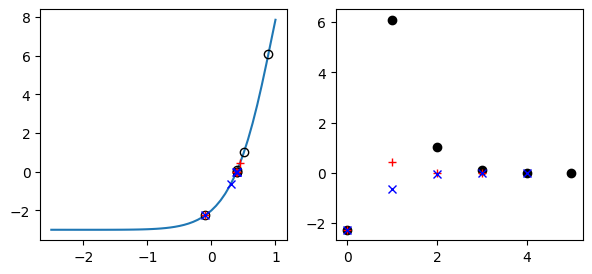

$$
\bigg(
\begin{matrix}
2x+y=5  \ \ \text{eq. (1)}\\
x-y=-1   \ \ \text{eq. (2)}
\end{matrix}
$$

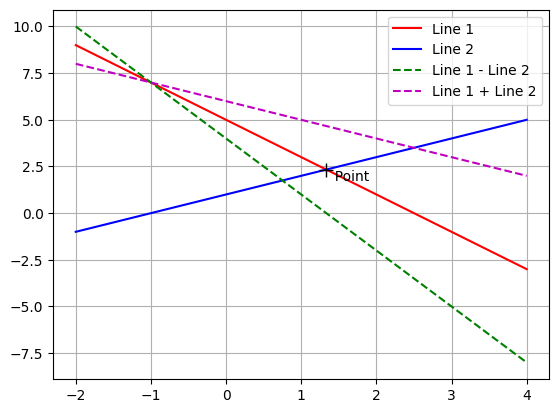

In [143]:
import matplotlib.pyplot as plt
import numpy as np

def y1(x):
    return 5-2*x
def y2(x):
    return x+1

xs=np.linspace(-2,4) ## -10~10 범위 내의 선 그리기
plt.plot(xs,y1(xs),'r-',label='Line 1')
plt.plot(xs,y2(xs),'b-',label='Line 2')
plt.plot(xs,y1(xs)-y2(xs),'g--',label='Line 1 - Line 2')
plt.plot(xs,y1(xs)+y2(xs),'m--',label='Line 1 + Line 2')
#plt.plot(xs,y1(xs)*y2(xs),'k--',label='Line 1 * Line 2')
plt.legend()
xy=(4/3,7/3)
plt.plot(*xy,marker='+',mfc='None',mec='k',ms=10)
plt.text(*xy,'  Point',va='top',ha='left')
plt.grid()

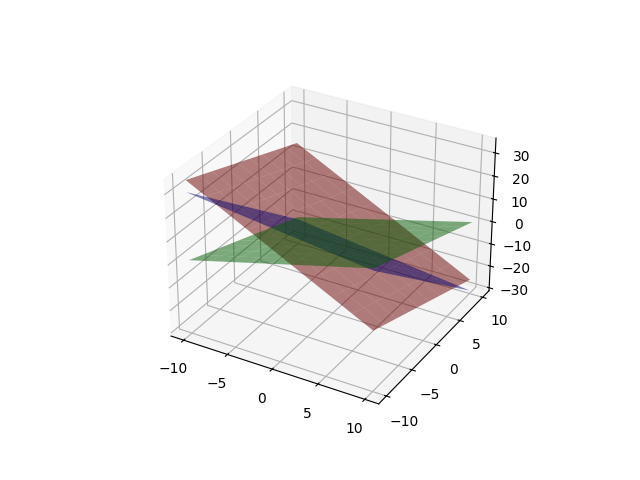

In [160]:
import matplotlib.pyplot as plt
import numpy as np
%matplotlib widget

def z1(x,y):
    return 5-2*x-y
def z2(x,y):
    return x-y+1
def z3(x,y):
    return (-x-5*y)/2.

nres=10
x=np.linspace(-10,10,nres)
y=np.linspace(-10,10,nres)
xx,yy=np.meshgrid(x,y)
zz1=z1(xx,yy)
zz2=z2(xx,yy)
zz3=z3(xx,yy)

fig=plt.figure()
ax1=fig.add_subplot(projection='3d')
kws=dict(alpha=0.5)
ax1.plot_surface(xx,yy,zz1,color='r',**kws)
ax1.plot_surface(xx,yy,zz2,color='g',**kws)
ax1.plot_surface(xx,yy,zz3,color='b',**kws)